# Analisis Exploratorio: Inflacion en Ecuador y economias de referencia (2014-2024)

Agente de Analisis Economico. Fuente: `data/processed/inflacion_pib_desempleo.csv` (Banco Mundial, consultado 2026-07-16).

Este notebook es exploratorio: reproduce en un entorno interactivo lo que `scripts/calculate_indicators.py` calcula de forma automatizada, para que el equipo pueda inspeccionar los datos paso a paso.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/inflacion_pib_desempleo.csv')
df.head(10)

,pais,codigo_iso3,indicador,anio,valor
0,América Latina y el Caribe,LAC,crecimiento_pib,2014,1.116413
1,América Latina y el Caribe,LAC,crecimiento_pib,2015,0.069939
2,América Latina y el Caribe,LAC,crecimiento_pib,2016,-0.977478
3,América Latina y el Caribe,LAC,crecimiento_pib,2017,1.587463
4,América Latina y el Caribe,LAC,crecimiento_pib,2018,1.152298
5,América Latina y el Caribe,LAC,crecimiento_pib,2019,0.182794
6,América Latina y el Caribe,LAC,crecimiento_pib,2020,-6.796400
7,América Latina y el Caribe,LAC,crecimiento_pib,2021,6.854513
8,América Latina y el Caribe,LAC,crecimiento_pib,2022,3.975960
9,América Latina y el Caribe,LAC,crecimiento_pib,2023,2.126810


In [2]:
df['indicador'].value_counts()

indicador
crecimiento_pib                 55
inflacion_precios_consumidor    55
tasa_desempleo                  55
Name: count, dtype: int64

## Evolucion de la inflacion por pais

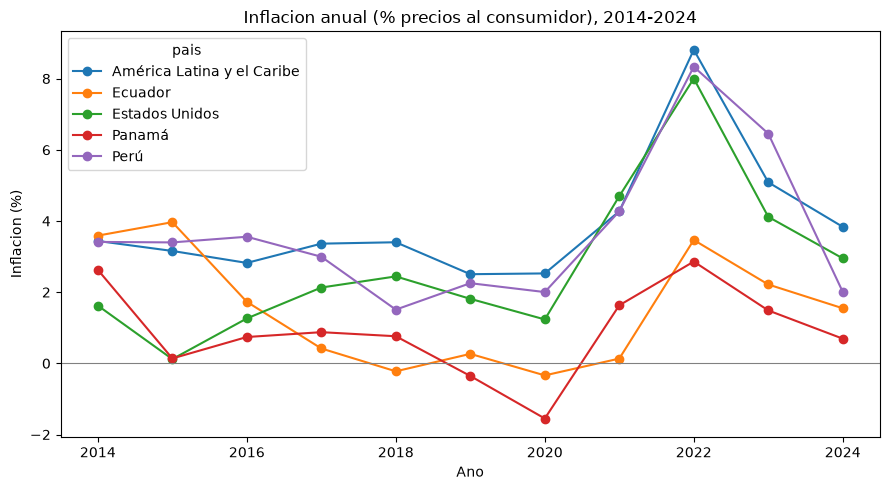

In [3]:
inflacion = df[df['indicador'] == 'inflacion_precios_consumidor']
pivot = inflacion.pivot(index='anio', columns='pais', values='valor')

ax = pivot.plot(figsize=(9, 5), marker='o')
ax.set_title('Inflacion anual (% precios al consumidor), 2014-2024')
ax.set_xlabel('Ano')
ax.set_ylabel('Inflacion (%)')
ax.axhline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/charts/evolucion_inflacion.png', dpi=150)
plt.show()

## Estadistica descriptiva rapida

In [4]:
inflacion.groupby('pais')['valor'].describe().round(2).sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
pais,,,,,,,,
Panamá,11.0,0.90,1.26,-1.55,0.42,0.76,1.56,2.86
Ecuador,11.0,1.52,1.61,-0.34,0.20,1.55,2.84,3.97
Estados Unidos,11.0,2.76,2.18,0.12,1.44,2.13,3.53,8.00
Perú,11.0,3.65,2.07,1.51,2.13,3.40,3.91,8.33
América Latina y el Caribe,11.0,3.93,1.79,2.50,2.99,3.40,4.05,8.81


**Interpretacion:** Panama y Ecuador -las dos economias dolarizadas de la muestra- presentan la
menor inflacion promedio y la menor dispersion del grupo. El detalle formal de estos indicadores,
con redondeo e interpretacion economica completa, se encuentra en `outputs/tables/indicadores_comparativos.csv`
y en `docs/informe_final.pdf` (seccion 10.1).

## Relacion entre inflacion y crecimiento del PIB (vista rapida)

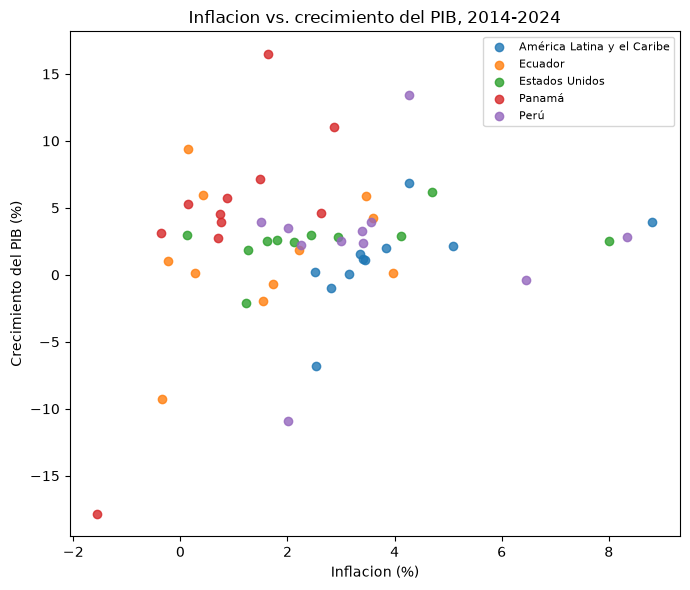

In [5]:
pib = df[df['indicador'] == 'crecimiento_pib'][['pais', 'anio', 'valor']].rename(columns={'valor': 'pib'})
infl = inflacion[['pais', 'anio', 'valor']].rename(columns={'valor': 'inflacion'})
merged = infl.merge(pib, on=['pais', 'anio'])

fig, ax = plt.subplots(figsize=(7, 6))
for pais, group in merged.groupby('pais'):
    ax.scatter(group['inflacion'], group['pib'], label=pais, alpha=0.8)
ax.set_xlabel('Inflacion (%)')
ax.set_ylabel('Crecimiento del PIB (%)')
ax.set_title('Inflacion vs. crecimiento del PIB, 2014-2024')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/charts/inflacion_vs_pib.png', dpi=150)
plt.show()

No se observa un patron lineal unico y claro entre ambas variables a simple vista; el analisis
formal de correlacion por pais (con p-valores) se realiza en `econometric_analysis.ipynb` y en
`scripts/econometric_model.py`.